# Sales Data Analysis

This notebook performs outlier detection, correlation analysis, normalization, standardization, and PCA on `sales_data.csv`.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

## 1. Load Dataset

In [14]:
df = pd.read_csv("sales_data.csv")
df.head()

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,2014-05-15,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418


## 1.1 Outlier Detection (IQR Method)

Cost: 18179 outliers
[ 1080  1125  1260 ...  2964 40014 42978]
Revenue: 14765 outliers
[ 2401  2088  2086 ...  4577 54069 58074]


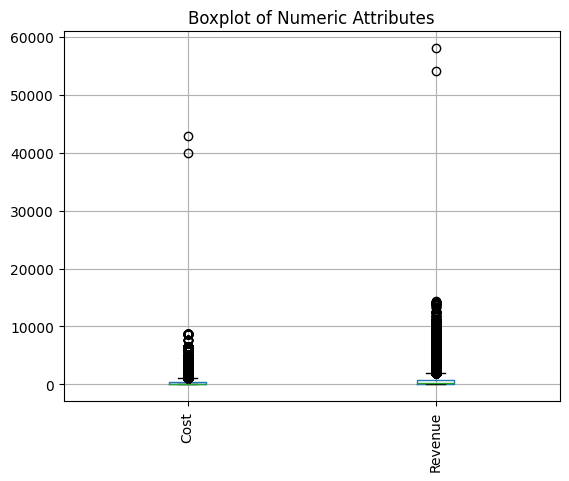

In [16]:
numeric_df = df[['Cost','Revenue']]

outliers = {}
for col in numeric_df.columns:
    Q1 = numeric_df[col].quantile(0.25)
    Q3 = numeric_df[col].quantile(0.75)
    IQR = Q3 - Q1
    mask = (numeric_df[col] < Q1 - 1.5*IQR) | (numeric_df[col] > Q3 + 1.5*IQR)
    outliers[col] = numeric_df[col][mask]

for col, vals in outliers.items():
    print(f"{col}: {len(vals)} outliers")
    print(vals.values)

numeric_df.boxplot(rot=90)
plt.title("Boxplot of Numeric Attributes")
plt.show()

## 1.2 Correlation Analysis (Outlier-Corrected Data)

In [17]:
# Remove outliers using IQR rule
clean_df = numeric_df.copy()
for col in clean_df.columns:
    Q1 = clean_df[col].quantile(0.25)
    Q3 = clean_df[col].quantile(0.75)
    IQR = Q3 - Q1
    clean_df = clean_df[(clean_df[col] > Q1 - 1.5*IQR) & (clean_df[col] < Q3 + 1.5*IQR)]

pearson_corr = clean_df.corr(method='pearson')
spearman_corr = clean_df.corr(method='spearman')

pearson_corr, spearman_corr

(             Cost   Revenue
 Cost     1.000000  0.919176
 Revenue  0.919176  1.000000,
              Cost   Revenue
 Cost     1.000000  0.980686
 Revenue  0.980686  1.000000)

## 1.3 Normalization and Standardization

In [18]:
# Min and Max
df_min = numeric_df.min()
df_max = numeric_df.max()
df_min, df_max

(Cost       1
 Revenue    2
 dtype: int64,
 Cost       42978
 Revenue    58074
 dtype: int64)

In [19]:
# Min-Max Normalization
mm = MinMaxScaler()
norm_data = mm.fit_transform(numeric_df)
norm_df = pd.DataFrame(norm_data, columns=numeric_df.columns)
norm_df.to_csv("sales_data_normalisation.csv", index=False)

In [20]:
# Standardization
sc = StandardScaler()
std_data = sc.fit_transform(numeric_df)
std_df = pd.DataFrame(std_data, columns=numeric_df.columns)
std_df.to_csv("sales_data_standardisation.csv", index=False)

numeric_df.mean(), numeric_df.std()

(Cost       469.318695
 Revenue    754.370360
 dtype: float64,
 Cost        884.866118
 Revenue    1309.094674
 dtype: float64)

## 1.4 Principal Component Analysis (PCA)

In [21]:
# Covariance Matrix
cov_matrix = np.cov(numeric_df.T)
eig_vals, eig_vecs = np.linalg.eig(cov_matrix)

eig_vals, eig_vecs

(array([  12073.7832895 , 2484643.12723014]),
 array([[-0.82958622, -0.55837864],
        [ 0.55837864, -0.82958622]]))

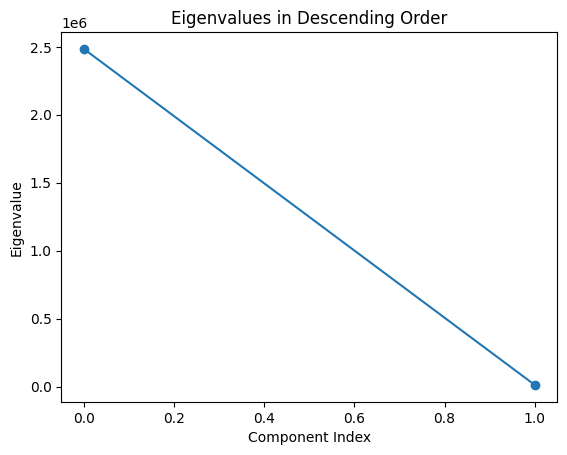

In [22]:
# Plot eigenvalues
plt.plot(sorted(eig_vals, reverse=True), marker='o')
plt.title("Eigenvalues in Descending Order")
plt.xlabel("Component Index")
plt.ylabel("Eigenvalue")
plt.show()

In [23]:
# PCA using sklearn
pca = PCA()
pca_data = pca.fit_transform(numeric_df)
pca.explained_variance_

array([2484643.12723014,   12073.7832895 ])